### Importamos las librerias que vamos a utilizar


In [3]:

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import warnings
# Ignorar todos los mensajes de advertencia
warnings.filterwarnings("ignore")

### Importamos el dataset para el practico

In [4]:

########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################

#Aplique la ruta correcta utilizando la ubicacion en donde alojo el archivo "data.csv"
ruta_archivo = r"C:\Users\Usuario\Desktop\Master Ciencia de Datos\Proyectos\DataScienceIEBS\Bloque 4\Aprendizaje NO supervisado\Proyecto\data.csv"

########################################################
##FIN DE LA PARTE A COMPLETAR
########################################################



# Leer el archivo CSV en un DataFrame
df = pd.read_csv(ruta_archivo)

print(df.shape)

# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar el conjunto de datos
df.sample(5)


(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
370,9012315,M,16.350,23.29,109.00,840.4,0.09742,0.14970,0.18110,0.08773,0.2175,0.06218,0.4312,1.0220,2.972,45.50,0.005635,0.03917,0.06072,0.016560,0.03197,0.004085,19.380,31.03,129.30,1165.0,0.1415,0.4665,0.70870,0.22480,0.4824,0.09614
228,88147202,B,12.620,23.97,81.35,496.4,0.07903,0.07529,0.05438,0.02036,0.1514,0.06019,0.2449,1.0660,1.445,18.51,0.005169,0.02294,0.03016,0.008691,0.01365,0.003407,14.200,31.31,90.67,624.0,0.1227,0.3454,0.39110,0.11800,0.2826,0.09585
152,8710441,B,9.731,15.34,63.78,300.2,0.10720,0.15990,0.41080,0.07857,0.2548,0.09296,0.8245,2.6640,4.073,49.85,0.010970,0.09586,0.39600,0.052790,0.03546,0.029840,11.020,19.49,71.04,380.5,0.1292,0.2772,0.82160,0.15710,0.3108,0.12590
358,9010333,B,8.878,15.49,56.74,241.0,0.08293,0.07698,0.04721,0.02381,0.1930,0.06621,0.5381,1.2000,4.277,30.18,0.010930,0.02899,0.03214,0.015060,0.02837,0.004174,9.981,17.70,65.27,302.0,0.1015,0.1248,0.09441,0.04762,0.2434,0.07431
535,919555,M,20.550,20.86,137.80,1308.0,0.10460,0.17390,0.20850,0.13220,0.2127,0.06251,0.6986,0.9901,4.706,87.78,0.004578,0.02616,0.04005,0.014210,0.01948,0.002689,24.300,25.48,160.20,1809.0,0.1268,0.3135,0.44330,0.21480,0.3077,0.07569


#### A continuacion graficaremos los datos, para evaluar cuantos tumores son benignos y malignos, la idea de este practico, es evaluar si aplicando un algoritmo de CLUSTERING, podemos encontrar 2 agrupaciones o mas, que nos permitan identificar si los tumores son benignos o malignos, de acuerdo al cluster que pertenezcan.

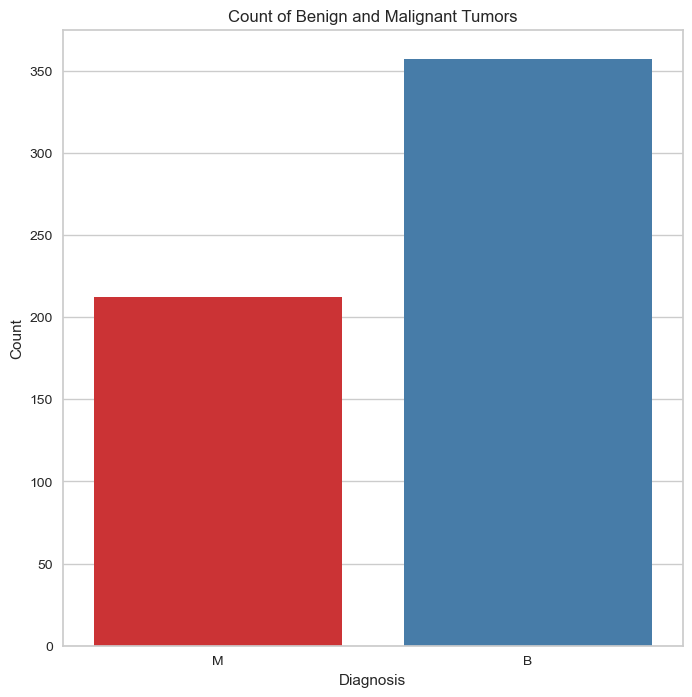

Number of Benign (B):  357
Number of Malignant (M):  212


In [5]:


# Crear un gráfico de conteo para la variable "diagnosis"
plt.figure(figsize=(8,8))
ax = sns.countplot(x='diagnosis', data= df, palette='Set1')
ax.set(xlabel='Diagnosis', ylabel='Count', title='Count of Benign and Malignant Tumors')
plt.show()

# Obtener y mostrar el número de casos benignos (B) y malignos (M)
B, M = df['diagnosis'].value_counts()
print('Number of Benign (B): ', B)
print('Number of Malignant (M): ', M)


#### Como se observa, aproximadamente un 63% de la muestra son tumores Benignos (357 casos), frente a un 37 % aproximado (212 casos) que corresponde a tumroes malignos. Podemos concluir que se trata de un dataset balanceado (no hay igualdad de "clases" pero tenemos suficientes casos de cada una).

##### Remplazamos el TARGET B y M, por 0 Y 1 respectivamente, para mas adelante realizar una Confusion Matrix y evaluar los resultados, de forma simple. A continuacion eliminamos las 2 columnas ID ya que no es un campo relevante para el algoritmo y el campo diagnosis que es el TARGET, o campo que utlizaremos para contrastar resultados, el foco de este practico es confirmar si los clusteres detectados permiten separar los 2 tipos de tumores.

In [6]:
# Convertir las etiquetas de "diagnosis" a números (0 y 1) para mas adelante hacer una Confusion Matrix
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Eliminar las columnas "diagnosis" e "id" del conjunto de características, solo dejamos las variables sin ningun target que permita identificar de antemano que tipo de tumor es
Y = df['diagnosis']
X = df.drop(['diagnosis', 'id'], axis=1)

X.sample(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
522,11.26,19.83,71.30,388.1,0.08511,0.04413,0.005067,0.005664,0.1637,0.06343,0.1344,1.0830,0.9812,9.332,0.004200,0.00590,0.003846,0.004065,0.01487,0.002295,11.93,26.43,76.38,435.9,0.1108,0.07723,0.02533,0.02832,0.2557,0.07613
33,19.27,26.47,127.90,1162.0,0.09401,0.17190,0.165700,0.075930,0.1853,0.06261,0.5558,0.6062,3.5280,68.170,0.005015,0.03318,0.034970,0.009643,0.01543,0.003896,24.15,30.90,161.40,1813.0,0.1509,0.65900,0.60910,0.17850,0.3672,0.11230
563,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.317400,0.147400,0.2149,0.06879,0.9622,1.0260,8.7580,118.800,0.006399,0.04310,0.078450,0.026240,0.02057,0.006213,24.29,29.41,179.10,1819.0,0.1407,0.41860,0.65990,0.25420,0.2929,0.09873
445,11.99,24.89,77.61,441.3,0.10300,0.09218,0.054410,0.042740,0.1820,0.06850,0.2623,1.2040,1.8650,19.390,0.008320,0.02025,0.023340,0.016650,0.02094,0.003674,12.98,30.36,84.48,513.9,0.1311,0.18220,0.16090,0.12020,0.2599,0.08251
346,12.06,18.90,76.66,445.3,0.08386,0.05794,0.007510,0.008488,0.1555,0.06048,0.2430,1.1520,1.5590,18.020,0.007180,0.01096,0.005832,0.005495,0.01982,0.002754,13.64,27.06,86.54,562.6,0.1289,0.13520,0.04506,0.05093,0.2880,0.08083


#FASE 1: ESTANDARIZAR LAS VARIABLES (obligatorio)

#### Estandarizamos las caracteristicas, para más adelante aplicar K-Means y que todas estén expresadas en la misma escala


In [7]:
# Estandarizar las características para el K-Means
#Escalar X y generar el vector llamado X_scaled
scaler = StandardScaler()

########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################

#Ajuste y transformacion de los datos
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

########################################################
##FIN DE LA PARTE A COMPLETAR
########################################################

#Visualizamos el vector con los datos escalados
X_scaled.sample(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
462,0.077453,1.791923,0.011573,-0.024997,-1.879499,-0.987580,-0.678462,-0.813778,-0.381957,-1.200372,-0.626819,-0.554560,-0.563869,-0.436010,-0.561682,-0.485576,-0.403976,-0.880172,-0.775181,-0.719776,-0.179994,1.026368,-0.204367,-0.256626,-1.344385,-0.688717,-0.599635,-0.898007,-0.899091,-1.069848
214,0.017810,1.051916,0.037111,-0.125678,-0.123136,0.497647,0.285006,0.404988,1.545741,0.217232,0.056044,1.139674,0.330651,-0.205432,1.279726,0.649540,0.165330,0.725704,2.960091,0.368075,0.122346,1.493730,0.230506,-0.121794,1.031520,0.964610,0.490362,0.953090,2.949609,1.033737
179,-0.374130,-1.449681,-0.439872,-0.415492,-0.638374,-1.262187,-0.999455,-0.918760,-1.261834,-0.208049,-0.419650,-0.411772,-0.538623,-0.408067,0.497694,-1.068280,-0.852590,-0.711798,-1.197745,-0.167907,-0.546530,-1.551449,-0.612433,-0.544747,-0.708765,-1.271103,-1.173515,-1.137522,-1.808284,-0.596042
141,0.563117,-0.288475,0.540867,0.449684,0.060471,0.177367,0.071195,0.271117,0.180289,-0.045025,1.081781,0.208915,0.825187,0.742402,-0.090330,-0.340822,-0.040575,-0.020461,-0.217009,-0.136512,0.756019,-0.066314,0.647508,0.619518,-0.042459,-0.195073,0.038435,0.106491,-0.175943,-0.131104
102,-0.553058,0.286311,-0.607516,-0.557982,-1.155035,-1.212155,-0.815688,-0.805266,-0.265127,-0.854476,-0.767939,0.642544,-0.833166,-0.564500,-0.653686,-1.083147,-0.703052,-0.810908,-0.735225,-0.855946,-0.606584,1.166414,-0.675579,-0.585004,-0.879725,-1.053734,-0.756514,-0.613574,-0.334485,-0.840426


# FASE 2: MÉTODO K-MEANS. MÉTODO ELBOW Y MÉTODO SILUETA (obligatorio)

#### A continuacion realizaremos varias iteraciones con el algoritmo K-means, para poder visualizar con el metodo de elbow, cual es el mejor valor de K, para este conjunto de datos.

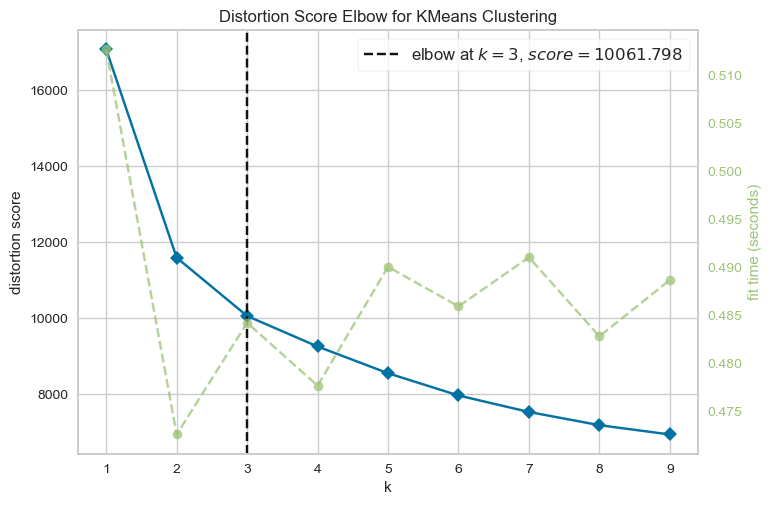

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [8]:
# Instantiate the clustering model and visualizer
seed = 42

km = KMeans(init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = KElbowVisualizer(km, k=(1,10))

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure



##### Aplicamos el método de ELBOW, y el resultado es que recomienda utilizar un valor de k=3, sin embargo visiblemente el codo se marca mejor con un k=2, además como ya sabemos de antemano que hay 2 tipos de tumores benignos y malignos, vamos a trabajar y considerar 2 grandes grupos, para más adelante contrastar, si los grupos identificados por el algoritmo, estan alineados a los 2 tipos de tumores.


#### A continuación vamos a aplicar el método de la silueta para entender qué valor de K es más conveniente. Esperemos que sean 2.

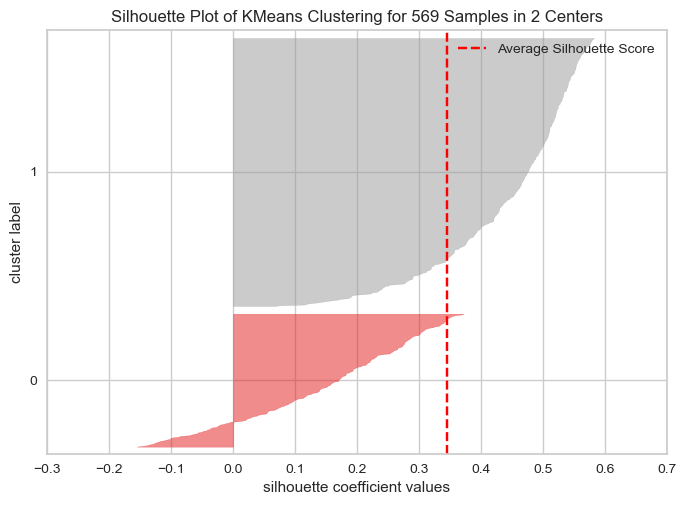

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 569 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [9]:

nclusters = 2
seed = 42

# Initialize KMeans for the Silhouette Visualizer
model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

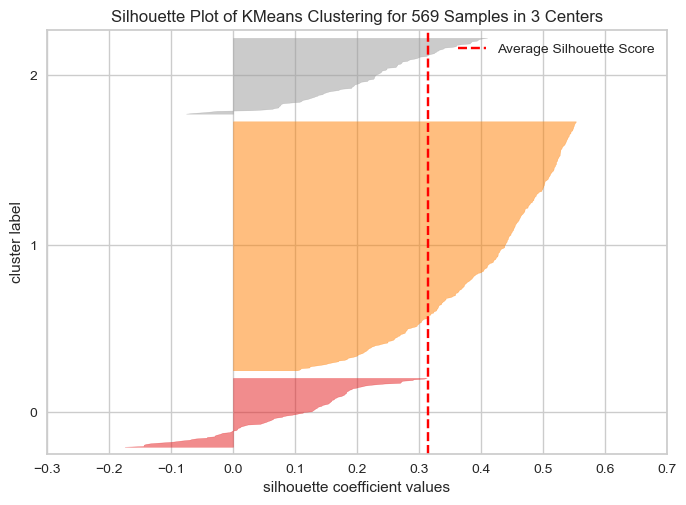

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 569 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [10]:
nclusters = 3
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

##### Luego de aplicar el método de la SILUETA confirmamos que 2 clusteres, es lo adecuado. Confirmando el análisis visual del metodo de elbow.

##### A conitnuación aplicaremos K-means, y luego una transformación simple, ya que K-means, asigna nombres aleatoriamente a los clusters detectados. Necesitamos forzar a que el CLUSTER MAYORITARIO el de mayor cantidad de elementos se le asigne el valor 0 y al minoritario 1. Para ir en linea, con el campo TARGET, ya que como confirmamos al inicio del análisis, identificamos que el grupo minoritario de tumores, son los del tipo maligno, por lo tanto le asignaremos el valor 1. Para que luego cuando utilicemos la matriz de confusion, se pueda considerar una coincidencia cuando ambos valores sean 1 o 0.

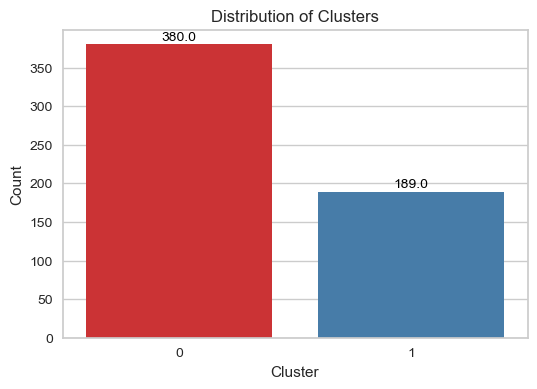

In [11]:
########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################

# Crear el modelo de K-Means con 2 clusters (benigno y maligno) ademas tiene mejor puntaje de SILUETA
# Utilizar kMeans con la variables n_clusters=2 a "X_scaled" y alojar el resultado en "df['cluster']" utilizando el metodo fit_predict

# Inicializamos el modelo Kmeans
kmeans_model = KMeans(n_clusters=2,
                init='k-means++',
                max_iter=300,
                n_init=10,
                random_state=42)

df['cluster'] = kmeans_model.fit_predict(X_scaled)

########################################################
##FIN DE LA PARTE A COMPLETAR
########################################################


# Obtener el tamaño de cada cluster
tamano_clusters = df['cluster'].value_counts()

# Determinar el cluster mayoritario
cluster_mayoritario = tamano_clusters.idxmax()

# Asignar etiquetas basadas en el cluster mayoritario
df['cluster'] = df['cluster'].apply(lambda x: 0 if x == cluster_mayoritario else 1)


# Crear un gráfico de barras para la distribución de clusters
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='cluster', data=df, palette='Set1')

# Agregar etiquetas con los números correspondientes a cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Distribution of Clusters')
plt.show()



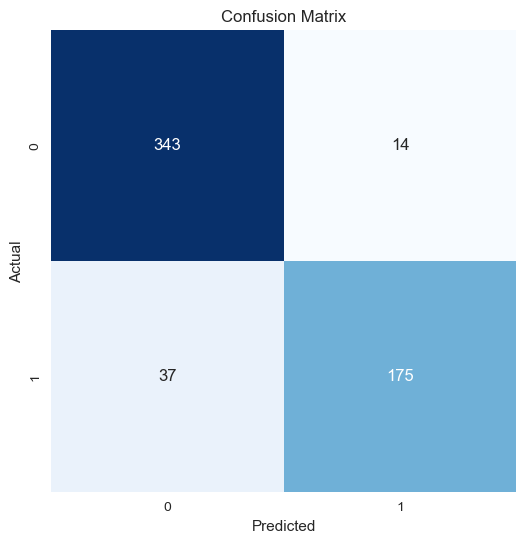

In [12]:

# Crear una matriz de confusión para comparar con el campo "diagnosis"
conf_matrix = confusion_matrix(df['diagnosis'], df['cluster'])

# Mostrar la matriz de confusión como un mapa de calor
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### La matriz de Confusion, presenta un MUY BUEN resultado, la mayoria de los casos estan bien clasificados, lo que indica que cada tipo de tumor, tiene caracteristicas muy distintivas que hacen que cada tipo de tumor sea muy identificable y pertenezca a un cluter especifico.


In [13]:
# Impartamos classification report para ver una evaluación más detallada de los resultados
from sklearn.metrics import classification_report
print(classification_report(df['diagnosis'], df['cluster']))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       357
           1       0.93      0.83      0.87       212

    accuracy                           0.91       569
   macro avg       0.91      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



# FASE 3: REDUCCIÓN DE DIMENSIONALIDAD - PCA VS T-SNE (obligatorio)

##### A continuacion aplicaremos PCA para poder visualizar en un grafico de 2 dimensiones los puntos, y poder pintar con colores diferentes cada cluster.

In [43]:
########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################
# Aplicar PCA para reducir la dimensionalidad a 2 componentes, para mejorar el entrenamiento y visualizar clusters
# Utilizar la libreria PCA con (n_components=2), aplicarlo a "X_scaled" y alojar el resultado en "X_pca"

n_componentes = 2
pca = PCA(n_components=n_componentes)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

########################################################
##FIN DE LA PARTE A COMPLETAR
########################################################


# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Varianza explicada por cada componente principal:", explained_variance)


Varianza explicada por cada componente principal: [0.44272026 0.18971182]


In [44]:
# Vamos a medir la Captura de Varianza Acumulada
explained_variance_acum = np.cumsum(explained_variance)
print("Varianza explicada acumulada:", explained_variance_acum[-1])

Varianza explicada acumulada: 0.6324320765155951


Esto nos muestra que la varianza acumulada es del 63%, lo cual podríamos considerarlo como un valor demasiado bajo para que fueran especialmente representativas las componentes principales formadas, dado que se encuentra por debajo del 70%, sin embargo es cierto que no dista mucho de este valor. Si elegimos 3 componentes principales entonces sí estaríamos por encima del 70%, tal como nos sugiere el método de Elbow. En este caso vemos como estas dos técnicas entran en conflicto dado que la sugerenciad el método del codo y el de la silueta no coinciden. Vamos a proseguir, sin embargo, con dos componentes tal como sugiere el ejercicio.

Aquí vemos que la varianza 

In [16]:
# Función para mostrar gráficamente los componentes de la PCA de 2 dimensiones
def plot_pca_projection(scores, components, y_target, labels=None, cmap="viridis", showlabels=True):
    
    x_scores = scores[:, 0] # 1er componente de PCA
    y_scores = scores[:, 1] # 2da componente de PCA
    num_variables = components.shape[0] # Número de variables originales

    # Ajustar tamaño de la figura
    plt.figure(figsize=(8, 6))


    # Escalar para mejor visualización
    scale_x = 1.0 / (x_scores.max() - x_scores.min())
    scale_y = 1.0 / (y_scores.max() - y_scores.min())
    
    x_lim = scale_x*x_scores.max() + 0.2*scale_x*x_scores.max()
    y_lim = scale_y*y_scores.max() + 0.2*scale_y*y_scores.max()

    plt.scatter(x_scores * scale_x, y_scores * scale_y, c=y_target, cmap= cmap, edgecolors='k', alpha=0.8)

    # Dibujar flechas y etiquetas con mejor separación
    for i in range(num_variables):
        plt.arrow(0, 0, components[i, 0] * 0.8, components[i, 1] * 0.8,
                  color='red', alpha=0.6, head_width=0.02)
        if showlabels == True:
            variable_label = labels[i] if labels else f"Var{i+1}"
            plt.text(components[i, 0] * 1.1, components[i, 1] * 1.1, variable_label,
                    color='green', fontsize=12, fontweight='bold', ha='center', va='center')

    plt.xlim(-x_lim, x_lim)
    plt.ylim(-y_lim, y_lim)
    plt.xlabel("Componente Principal 1", fontsize=14, fontweight='bold')
    plt.ylabel("Componente Principal 2", fontsize=14, fontweight='bold')
    plt.title("Proyección de PCA con Flechas de Variables", fontsize=16, fontweight='bold')
    plt.grid(alpha=0.5)
    
    plt.show()
    return None

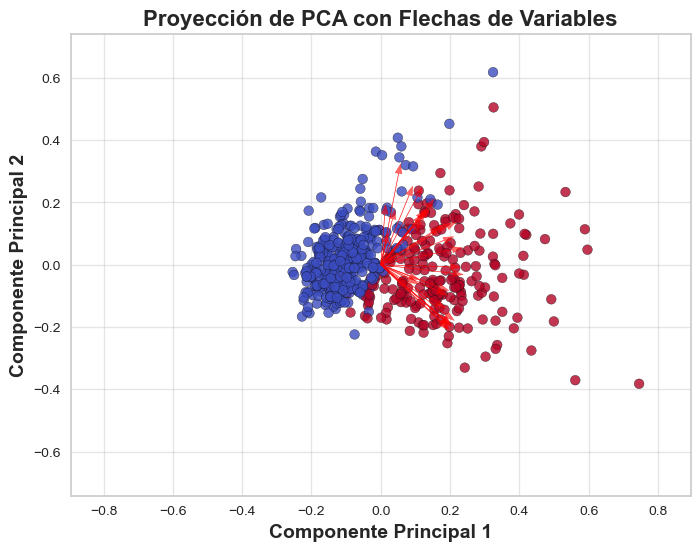

In [17]:
# Llamamos a la función con los datos de PCA y los componentes
plot_pca_projection(X_pca, np.transpose(pca.components_),Y ,labels=list(X.columns), cmap='coolwarm', showlabels= False)

##### Se puede observar que la varianza capturada con 2 componenentes principales es del 63% un valor bastante bajo, quiere decir que no representan fielmente a las originales, de todos modos vamos a visualizar los puntos. como valor agregado podrian utilizar un grafico 3D para lograr una mayor captura de varianza, y tener una visualizacion de los puntos mas confiable.

In [18]:
# Crear un DataFrame con las nuevas variables PCA
df_pca = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])

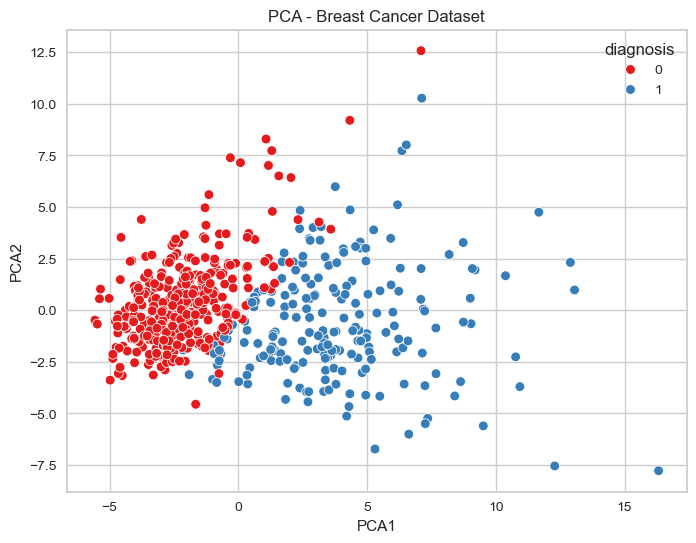

In [19]:
# Añadir la columna "diagnosis" al DataFrame PCA
df_pca['diagnosis'] = df['diagnosis']

# Visualizar el resultado en un scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='diagnosis', data=df_pca, palette='Set1')
plt.title('PCA - Breast Cancer Dataset')
plt.show()

##### A pesar del bajo grado de explicabilidad, se visualizan 2 clusters separados por una linea IMAGINARIA, no se detecta un espacio que los diferencie claramente.

In [20]:
# Seleccionar las nuevas características PCA para clustering
X_pca_for_clustering = df_pca[['PCA1', 'PCA2']]

In [21]:
########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################
# Crear el modelo de K-Means con 2 clusters
# Utilizar kMeans con la variables n_clusters=2 a "X_pca_for_clustering" y alojar el resultado en "df_pca['cluster_pca']" utilizando el metodo fit_predict
# La idea es aplicar nuevamente K-means como antes, pero en vez utilizarlo en "X_scaled", lo aplicaremos directamente en "X_pca_for_clustering", que tiene solo
# 2 componentes luego de aplicar PCA, buscando mejorar los resultados y tiempos de ejecucion.



# Inicializamos KMeans con 2 clusters
Kmeas_pca = KMeans(n_clusters=2, 
                init='k-means++',
                max_iter=500,
                n_init=10,
                random_state= 42)

# Entrenamos el modelo y predecimos los clusters
df_pca['cluster_pca'] = Kmeas_pca.fit_predict(X_pca_for_clustering)

########################################################
##FIN DE LA PARTE A COMPLETAR
########################################################

# Obtener el tamaño de cada cluster
tamano_clusters = df_pca['cluster_pca'].value_counts()

# Determinar el cluster mayoritario
cluster_mayoritario = tamano_clusters.idxmax()

# Asignar etiquetas basadas en el cluster mayoritario
df_pca['cluster_pca'] = df_pca['cluster_pca'].apply(lambda x: 0 if x == cluster_mayoritario else 1)

# Mostrar el resultado
print(df_pca['cluster_pca'].value_counts())



cluster_pca
0    378
1    191
Name: count, dtype: int64


##### Aplicamos nuevamente clustering, pero ahora en vez de trabajar con todo el dataset escalado, direcamente utilizamos las 2 componenentes principales identificadas, con esto queremos validar si obtenemos un mejor resultado, y en menor tiempo de ejecucion. Para validar si es verdad las ventajas que promete PCA, a la hora de entrenar algoritmos.  Como punto extra podria realizar mediciones del tiempo de entrenamiento de ambos algoritmos, entrenando un modelo k-means con 2 componentes principales vs trabajar con las variables originales que son muchas mas.

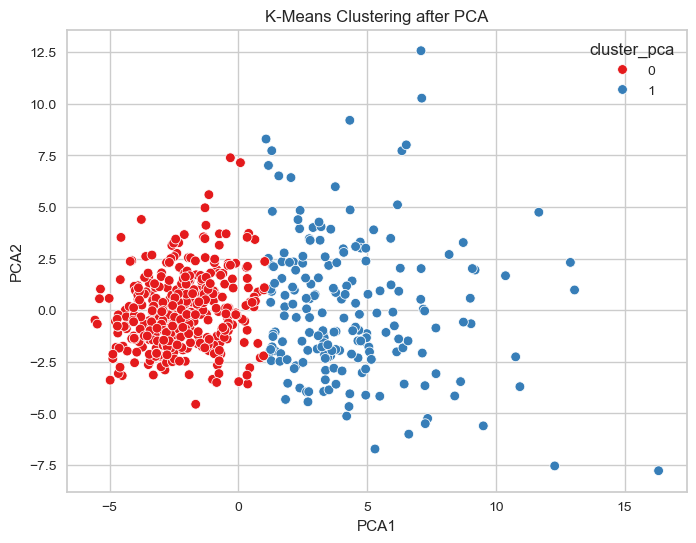

In [22]:
# Visualizar el resultado en un scatter plot con los clusters de K-Means
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_pca', data=df_pca, palette='Set1', legend='full')
plt.title('K-Means Clustering after PCA')
plt.show()

In [23]:
# Vamos a evaluar el tiempo de ejecución del entrenamiento de Kmeans con PCA y sin PCA
import timeit

# Entrenar KMeans con las características originales
start_time = timeit.default_timer()
kmeans_original = KMeans(n_clusters=2, random_state=42).fit(X)
end_time = timeit.default_timer()
execution_time_original = end_time - start_time
print("Tiempo de ejecución con características originales:", execution_time_original, "segundos")

# Entrenar KMeans con PCA
start_time = timeit.default_timer()
kmeans_pca = KMeans(n_clusters=2, random_state=42).fit(X_pca_for_clustering)
end_time = timeit.default_timer()
execution_time_pca = end_time - start_time
print("Tiempo de ejecución con PCA:", execution_time_pca, "segundos")


Tiempo de ejecución con características originales: 0.4641107000061311 segundos
Tiempo de ejecución con PCA: 0.47225270001217723 segundos


Como podemos comprobar, el empleo de la PCA no mejora realmente el tiempo de ejecución del algoritmo en este caso, ambos son bastante reducidos, y aunque la diferencia es corta, vemos como en este caso Kmeans entrena ligeramente más rápido con todas las componentes originales que únicamente con las dos componentes de PCA.

In [24]:
df_pca.sample(20)

,PCA1,PCA2,diagnosis,cluster_pca
93,-1.964950,-0.965157,0,0
495,-1.474920,-1.591094,0,0
246,-3.228770,-1.172073,0,0
23,4.208524,-5.128367,1,1
295,-3.315000,-1.442176,0,0
505,1.076693,8.294775,0,1
425,-4.703042,-0.432302,0,0
159,-4.680212,-1.103857,0,0
9,6.351747,7.727174,1,1
309,-4.027542,-2.542907,0,0


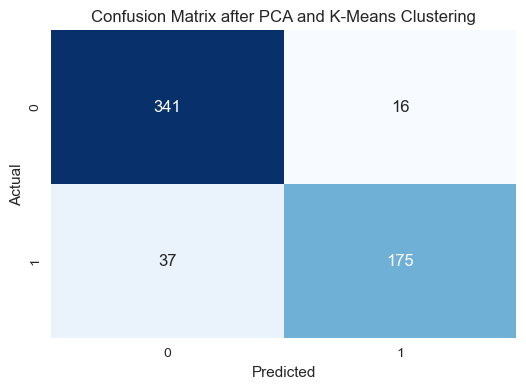

In [25]:
# Crear una matriz de confusión para comparar los clusters con el campo "diagnosis"
conf_matrix_pca = confusion_matrix(df_pca['diagnosis'], df_pca['cluster_pca'])

# Mostrar la matriz de confusión como un mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_pca, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after PCA and K-Means Clustering')
plt.show()


##### Cuando analizamos la precision con PCA, logramos una MEJORA MINIMA, practicamente es el mismo resultado, en este caso, no logramos una mejora sustancial en el resultado, pero seguramente si se tratara de un volumen muy grande de datos, seria mejor entrenar el modelo con las nuevas variables, ya que el algoritmo logra practicamente el mismo resultado, con menor coste computacional.  Por otro lado utilizar 3 componentes podria generar alcanzar un mejor resultado, ya que confirmamos que las 2 componentes principales no representan con gran fiabilidad a las originales.

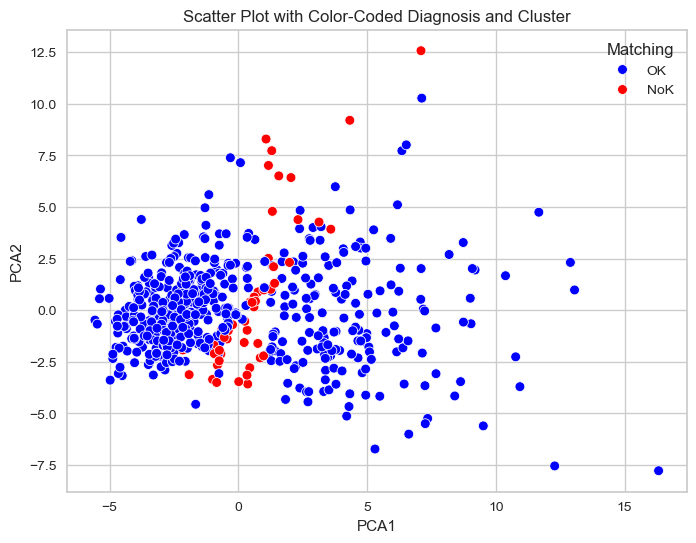

In [26]:
# Crear un scatter plot
plt.figure(figsize=(8, 6))

# Asignar colores según la lógica dada
colors = df_pca.apply(lambda row: 'OK' if row['diagnosis'] == row['cluster_pca'] else 'NoK', axis=1)

sns.scatterplot(x='PCA1', y='PCA2', data=df_pca, hue=colors, palette=['blue', 'red'], s=50)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Scatter Plot with Color-Coded Diagnosis and Cluster')
plt.legend(title='Matching')
plt.show()


##### En este grafico marcamos en ROJO los casos mal clasificados, y realmente es algo esperable, ya que son casos que se encuentran en la division de los 2 clusters, por lo tanto, existian grandes posibilidades de que sean mal clasificados, un punto importante aqui, seria evaluar otro metodo de reduccion de dimensionalidad, que separe mas los puntos o evaluar otro algoritmo de clustering para confirmar si se arriba a mejores resultados.  Tambien se podria evaluar trabajar con mas componentes principales, ya que la representatividad de solo 2 componentes es baja. Aqui se compara el TARGET orginal vs Cluster identificado.

##### De todos modos considero, que el algoritmo de CLUSTERING logro un RESULTADO EXCELENTE, clasificando la mayoria de los casos de forma correcta de los 569 casos, 516 fueron clasificados correctamente. Logrando una precision del 90.6%

##### Lo mas interesante de esto, es que el problema encontro una solucion utilizando un algoritmo de CLUSTERING, y seria util en el caso de datos NO ETIQUETADOS. Aqui solo usamos las etiquetas, para que se pueda realizar una comparacion entre el resultado obtenido, y una clasificacion real.


In [27]:
# Aplicar TSNE para reducir la dimensionalidad a 2 componentes, para mejorar el entrenamiento y visualizar clusters

from sklearn.manifold import TSNE


########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################
# Aplicar t-SNE para reducir la dimensionalidad a 2 componentes, para mejorar el entrenamiento y visualizar clusters, similar a PCA, pero ahora aplicamos otro algoritmo
# Utilizar la libreria TSNE con (n_components=2), aplicarlo a "X_scaled" y alojar el resultado en "X_tsne"

tsne = TSNE(n_components=2,
            random_state=42,
            n_iter=300,
            perplexity=20)

X_tsne = tsne.fit_transform(X_scaled)
########################################################
##FIN DE LA PARTE A COMPLETAR
########################################################


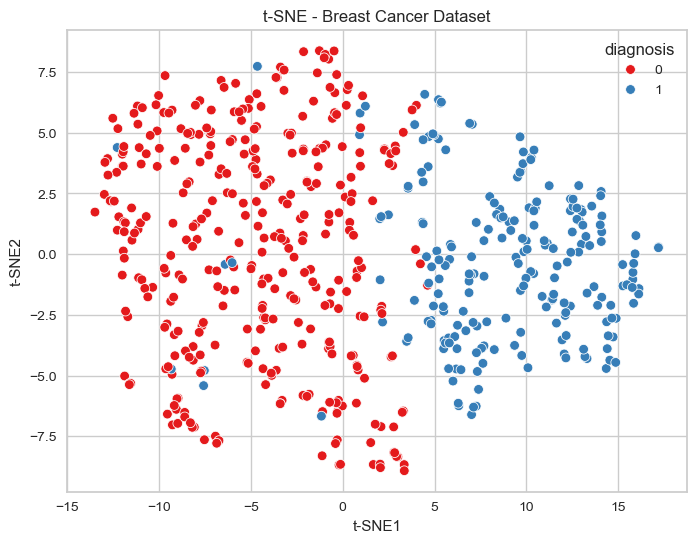

In [28]:
# Crear un DataFrame con las nuevas variables t-SNE
df_tsne = pd.DataFrame(data=X_tsne, columns=['t-SNE1', 't-SNE2'])

# Añadir la columna "diagnosis" al DataFrame t-SNE
df_tsne['diagnosis'] = df['diagnosis']

# Visualizar el resultado en un scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='diagnosis', data=df_tsne, palette='Set1')
plt.title('t-SNE - Breast Cancer Dataset')
plt.show()



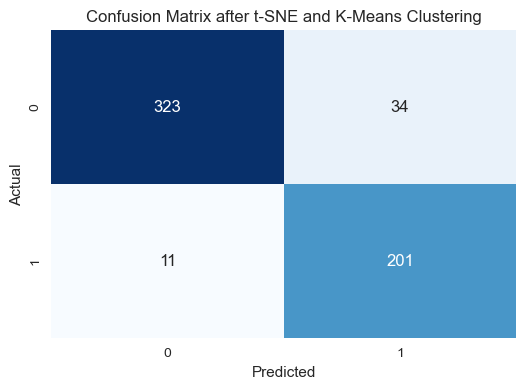

In [29]:
# Seleccionar las nuevas características t-SNE para clustering
X_tsne_for_clustering = df_tsne[['t-SNE1', 't-SNE2']]

# Crear el modelo de K-Means con 2 clusters
kmeans_tsne = KMeans(n_clusters=2, random_state=42)
df_tsne['cluster_tsne'] = kmeans_tsne.fit_predict(X_tsne_for_clustering)

# Obtener el tamaño de cada cluster
tamano_clusters_tsne = df_tsne['cluster_tsne'].value_counts()

# Determinar el cluster mayoritario
cluster_mayoritario_tsne = tamano_clusters_tsne.idxmax()

# Asignar etiquetas basadas en el cluster mayoritario
df_tsne['cluster_tsne'] = df_tsne['cluster_tsne'].apply(lambda x: 0 if x == cluster_mayoritario_tsne else 1)


# Crear una matriz de confusión para comparar los clusters con el campo "diagnosis"
conf_matrix_tsne = confusion_matrix(df_tsne['diagnosis'], df_tsne['cluster_tsne'])

# Mostrar la matriz de confusión como un mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tsne, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after t-SNE and K-Means Clustering')
plt.show()


In [30]:
# Evaluamos los resultados del clustering con PCA vs. TSNE con classificationreport
print("Resultados de clustering con TSNE:")
print(classification_report(df_tsne['diagnosis'], df_tsne['cluster_tsne']))

print("\n")
print("Resultados de clustering con PCA:")
print(classification_report(df_pca['diagnosis'], df_pca['cluster_pca']))

# Comparamos con el resultado sin reducción de dimensionalidad
print("\n")
print("Resultados de clustering sin reducción de dimensionalidad:")
print(classification_report(df['diagnosis'], df['cluster']))

Resultados de clustering con TSNE:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       357
           1       0.86      0.95      0.90       212

    accuracy                           0.92       569
   macro avg       0.91      0.93      0.92       569
weighted avg       0.93      0.92      0.92       569



Resultados de clustering con PCA:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       357
           1       0.92      0.83      0.87       212

    accuracy                           0.91       569
   macro avg       0.91      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



Resultados de clustering sin reducción de dimensionalidad:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       357
           1       0.93      0.83      0.87       212

    accuracy                           0.91       

# FASE4: CONCLUSIONES (obligatorio)

Las métricas son muy similares, sin embargo dado que se trata de establecer un diagnóstico de malignidad en tumores, los falsos positivos nos preocupan mucho menos que los falsos negativos, puesto que las consecuencias últimas serán peores en este segundo caso. Por ello, de acuerdo con la definición de precision y recall, la métrica que nos interesa es la de recall, puesto que tiene en cuenta la tasa de TP/(TP+FN), ergo maximizar el recall implica que estamos disminuyendo el número de falsos negativos.

En este caso, el recall más elevado para 1, es decir para el diagnóstico de malignidad, es de 95% tras la reducción de dimensionalidad aplicando TSNE, frente a un 83% empleando PCA, lo que implica que el modelo entrenado mediante K-means con los datos de TSNE es más apropiado para este caso, ayudnado a clasificar tumores malignos con un menor riesgo de emitir falsos negativos, que implicarían un severo riesgo para el paciente.

Estos resultados mejoran incluso aquellos obtenidos empleando el conjunto completo de datos, tal como vemos por el análisis de las métricas de la clasificación obtenida sin aplicar ningún algoritmo de reducción de dimensionalidad. Es por ello que de estos tres casos, el mejor algoritmo para aplicar en este caso es el de K-means con TSNE, aunque son muy similares en casi todas las métricas, pero destacamos el resultado de recall por los motivos ya mencionados.

Sin embargo podemos probar otros algoritmos de clustering para tratar de hallar mejores resultados, dado que como vemos en la región intermedia se encuetran los datos mal clasificados, lo que nos indica que k-means no es capaz de realizad una buena división de los subespacios, de modo que vamos a tratar de aplicar otros algoritmos más sensibles a este tipo de datos, como el de DBSCAN o GaussianMixture.

In [31]:
########################################################
##INICIO DE LA PARTE A COMPLETAR
########################################################

##### Incluir sus CONCLUSIONES, sobre el analisis y el desarrollo aqui expuesto (Necesario)
##### Profundizar aplicando otros algoritmos de CLUSTERING y reduccion de dimensionalidad, para intentar encontrar un mejor resultado (Opcional)

# Vamos a realizar otra prueba empleando Gaussian Mixture Model (GMM) para clustering
from sklearn.mixture import GaussianMixture

#Probaremos con los datos completos, y con las componentes extraidas por PCA y TSNE
gmm_full = GaussianMixture(n_components=2, random_state=42)
gmm_pca = GaussianMixture(n_components=2, random_state=42)
gmm_tsne = GaussianMixture(n_components=2, random_state=42)

# Ajustamos los datos con el modelo
gmm_full.fit(X_scaled)
gmm_pca.fit(X_pca)
gmm_tsne.fit(X_tsne)

# Obtenemos las etiquetas de los clusters
y_gmm = gmm_full.predict(X_scaled)
y_pca_gmm = gmm_pca.predict(X_pca)
y_tsne_gmm = gmm_tsne.predict(X_tsne)

# Añadimos el resultado a los dataframes
df['gmm_cluster'] = y_gmm
df_pca['gmm_cluster'] = y_pca_gmm
df_tsne['gmm_cluster'] = y_tsne_gmm



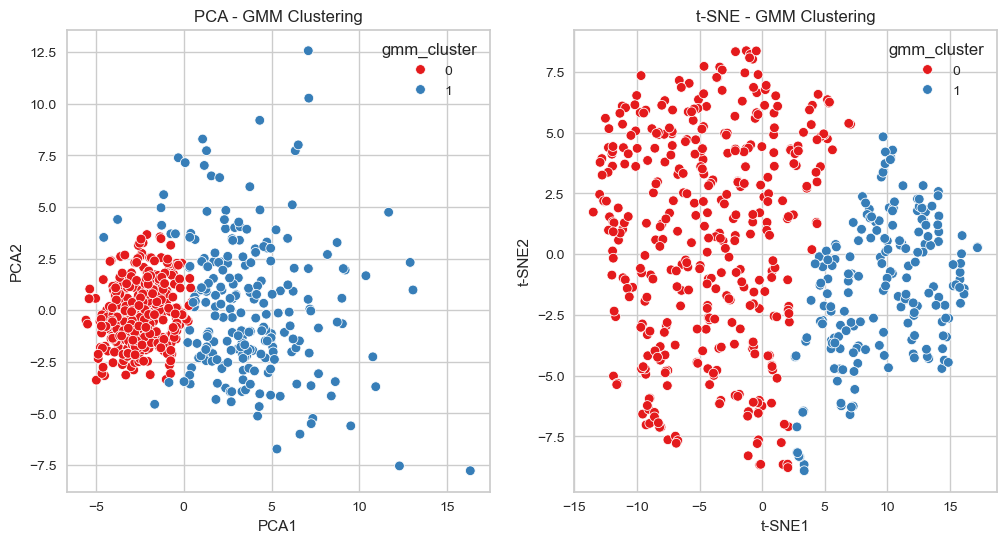

In [32]:
# Graficamos los resultados de PCA y TSNE con GMM
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='gmm_cluster', data=df_pca, palette='Set1')
plt.title('PCA - GMM Clustering')

plt.subplot(1, 2, 2)
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='gmm_cluster', data=df_tsne, palette='Set1')
plt.title('t-SNE - GMM Clustering')

plt.show()

In [33]:
# Comparamos los resultados obtenidos con GMM
print("Resultados de clustering con GMM y PCA:")
print(classification_report(df_pca['diagnosis'], df_pca['gmm_cluster']))
print("\n")
print("Resultados de clustering con GMM y TSNE:")
print(classification_report(df_tsne['diagnosis'], df_tsne['gmm_cluster']))
print("\n")
print("Resultados de clustering con GMM y datos completos:")
print(classification_report(df['diagnosis'], df['gmm_cluster']))
print("\n")

Resultados de clustering con GMM y PCA:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       357
           1       0.85      0.90      0.88       212

    accuracy                           0.91       569
   macro avg       0.90      0.90      0.90       569
weighted avg       0.91      0.91      0.91       569



Resultados de clustering con GMM y TSNE:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       357
           1       0.93      0.83      0.88       212

    accuracy                           0.91       569
   macro avg       0.92      0.90      0.91       569
weighted avg       0.91      0.91      0.91       569



Resultados de clustering con GMM y datos completos:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       357
           1       0.91      0.92      0.92       212

    accuracy                           0.94  

In [34]:
# El mejor resultado de GMM lo obtenemos con los datos completos
# Vamos a comprar GMM y datos completos con Kmean y t-SNE
print("Resultados de clustering con GMM y datos completos:")
print(classification_report(df['diagnosis'], df['gmm_cluster']))
print("\n")
print("Resultados de clustering con KMeans y t-SNE:")
print(classification_report(df_tsne['diagnosis'], df_tsne['cluster_tsne']))
print("\n")

Resultados de clustering con GMM y datos completos:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       357
           1       0.91      0.92      0.92       212

    accuracy                           0.94       569
   macro avg       0.93      0.94      0.93       569
weighted avg       0.94      0.94      0.94       569



Resultados de clustering con KMeans y t-SNE:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       357
           1       0.86      0.95      0.90       212

    accuracy                           0.92       569
   macro avg       0.91      0.93      0.92       569
weighted avg       0.93      0.92      0.92       569





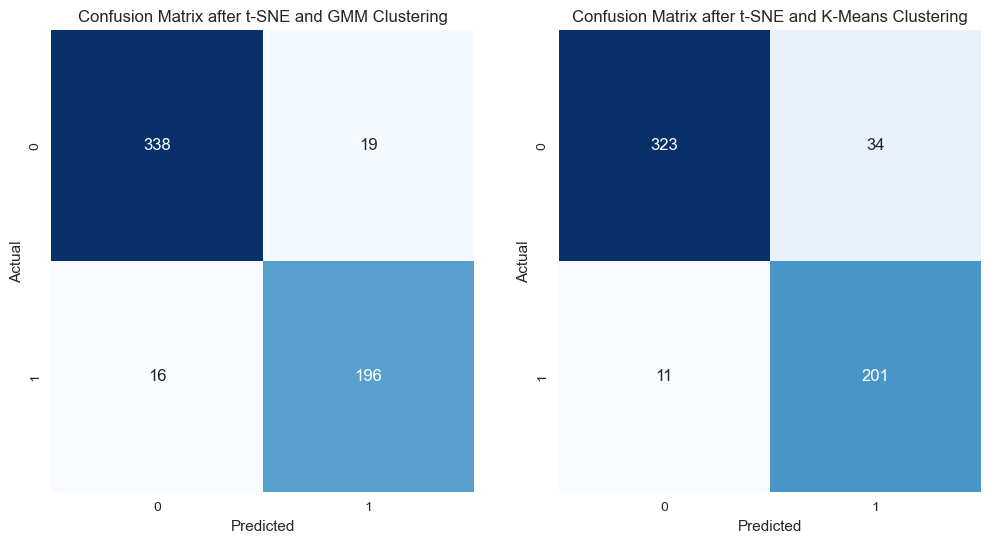

In [70]:
# Vemos una matriz de confusión para comparar los resultados de GMM y KMeans con t-SNE
conf_matrix_gmm = confusion_matrix(df['diagnosis'], df['gmm_cluster'])
conf_matrix_kmeans = confusion_matrix(df_tsne['diagnosis'], df_tsne['cluster_tsne'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_gmm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after t-SNE and GMM Clustering')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_kmeans, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after t-SNE and K-Means Clustering')

plt.show()

In [71]:
# En este caso GMM con datos completos es el mejor modelo, seguido de KMeans con t-SNE
# Comparemos el tiempo de ejecución de ambos
start_time = timeit.default_timer()
gmm_full = GaussianMixture(n_components=2, random_state=42).fit(X_scaled)
end_time = timeit.default_timer()
execution_time_gmm = end_time - start_time
print("Tiempo de ejecución con GMM y datos completos:", execution_time_gmm, "segundos")

start_time = timeit.default_timer()
kmeans_tsne = KMeans(n_clusters=2, random_state=42).fit(X_tsne_for_clustering)
end_time = timeit.default_timer()
execution_time_kmeans_tsne = end_time - start_time
print("Tiempo de ejecución con KMeans y t-SNE:", execution_time_kmeans_tsne, "segundos")

Tiempo de ejecución con GMM y datos completos: 0.07843580000917427 segundos
Tiempo de ejecución con KMeans y t-SNE: 0.4741009999997914 segundos


En este caso, atendiendo a las métricas ya comentadas anteriormente, constatamos que a pesar de que Gaussian Mixture es un modelo mucho más eficiente a pesar de emplear la totalidad de los datos, computacionalmente hablando, genera una mayor cantidad de falsos negativos que el modelo de K-means empleando las dos componentes principales generadas tras la reducción de dimensionalidad por t-SNE. Por ende, a pesar de que los resultados de precisión y exactitud sean similares, deberíamos seguir escogiendo el modelo de K-means con t-SNE para este caso. Aunque, si en algún momento el volumen de datos creciera en gran medida, Gaussian Mixture sería una gran alternativa por su precisión y su alta eficiencia.

Vamos a probar a continuación con DBSCAN, y compararemos los resultados con Gaussian Mixture.

In [37]:
# Probamos ahora con el modelo DBSCAN
from sklearn.cluster import DBSCAN

# Probamos con los datos completos, y con las componentes extraidas por PCA y TSNE
dbscan_full = DBSCAN(eps=1, min_samples=20, n_jobs=-1)
dbscan_pca = DBSCAN(eps=1, min_samples=20, n_jobs=-1)
dbscan_tsne = DBSCAN(eps=1, min_samples=20, n_jobs=-1)

# Obtenemos las clasificación de los clusters
y_dbscan = dbscan_full.fit_predict(X_scaled)
y_pca_dbscan = dbscan_pca.fit_predict(X_pca)
y_tsne_dbscan = dbscan_tsne.fit_predict(X_tsne)

# Añadimos los resultados a los dataframes
df['dbscan_cluster'] = y_dbscan
df_pca['dbscan_cluster'] = y_pca_dbscan
df_tsne['dbscan_cluster'] = y_tsne_dbscan

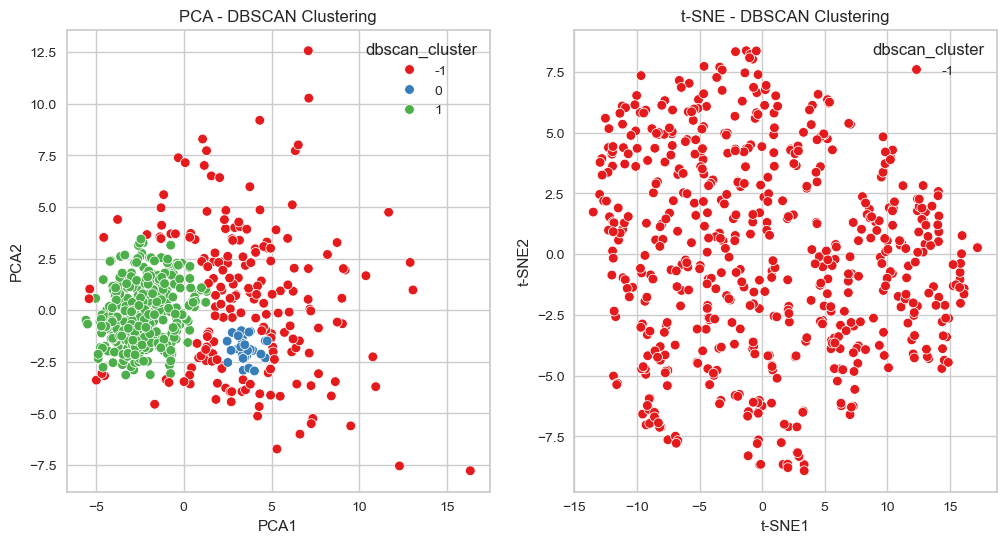

In [38]:
# Graficamos los resultados para PCA y TSNE con DBSCAN
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='dbscan_cluster', data=df_pca, palette='Set1')
plt.title('PCA - DBSCAN Clustering')

plt.subplot(1, 2, 2)
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='dbscan_cluster', data=df_tsne, palette='Set1')
plt.title('t-SNE - DBSCAN Clustering')

plt.show()

In [39]:
#Veamos cuantos clusters se han formado con DBSCAN y los datos al completo
df['dbscan_cluster'].value_counts()

dbscan_cluster
-1    569
Name: count, dtype: int64

Una simple inspección nos muestra que DBSCAN es incapaz de formar los clusters adecuadamente, a pesar de haber probado con varios valores al instanciar el modelo, bien aparecen demasiados clusters o muy pocos. Para este caso donde sabemos de antemano cuantos clusters se han de definir y estos no están claramente diferenciados, no parece ser una elección apropiada como algoritmo.

Tal como sugería el método del Codo y parecía indicar nuestro análisis de varianza, vamos a probar a mejorar el resultado aplicando una reducción de dimensionalidad diferente, con 3 componentes principales, como sugería inicialmente el método del codo. Para ello, usaremos en este caso el método de autovalores del laplaciano, también conocido como Spectral Embeddin en la biblioteca sklearn.



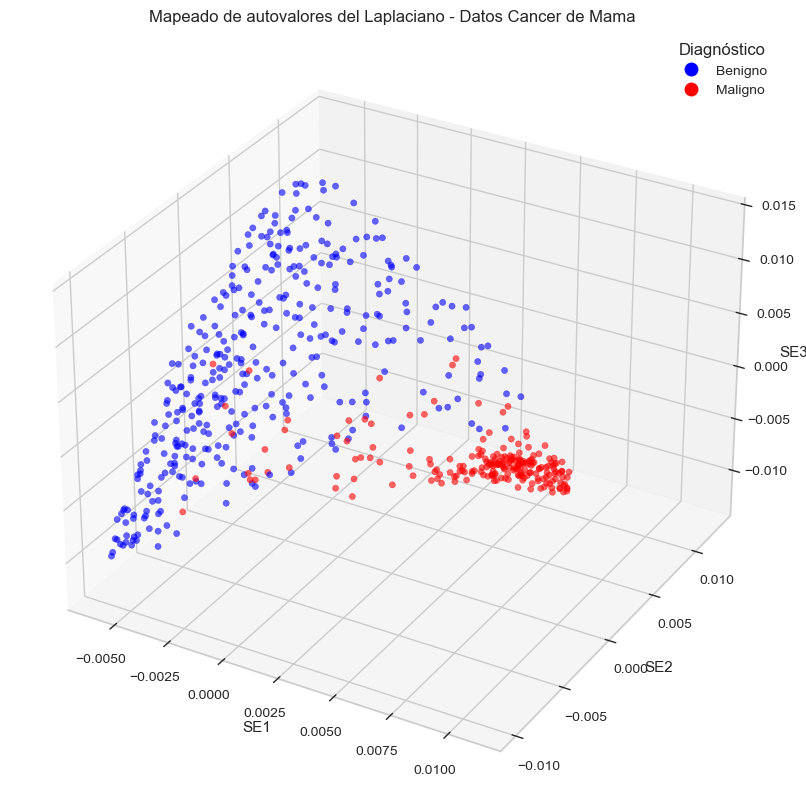

In [91]:
# Importamos la función
from sklearn.manifold import SpectralEmbedding

# Inicializamos el Spectral Embedding para reducir la dimensionalidad a 3 componentes
se = SpectralEmbedding(n_components=3, random_state=42)

# Aplicamos Spectral Embedding a los datos escalados
X_sc = se.fit_transform(X_scaled)

# Creamos un DataFrame con las nuevas variables
df_se = pd.DataFrame(data=X_sc, columns=['SE1', 'SE2', 'SE3'])
df_se['diagnosis'] = df['diagnosis']

# Visualizamos el resultado en un scatter plot 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Asignamos colores según la variable objetivo
colors = {0: 'blue', 1: 'red'}
df_se['color'] = df_se['diagnosis'].map(colors)

ax.scatter(df_se['SE1'], df_se['SE2'], df_se['SE3'], c=df_se['color'], s=20, alpha=0.6)
ax.set_xlabel('SE1')
ax.set_ylabel('SE2')
ax.set_zlabel('SE3')

# Añadimos la leyenda de los datos a la gráfica
legend_labels = ['Benigno', 'Maligno']
scatter_legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors.values()]
plt.legend(scatter_legend, legend_labels, title="Diagnóstico")

# Añadimos el título
plt.title('Mapeado de autovalores del Laplaciano - Datos Cancer de Mama ')

# Mostramos la gráfica
plt.show()

In [51]:
# Ahora vamos a aplicar KMeans a los datos obtenidos con Spectral Embedding
# Inicializamos KMeans con 2 clusters
kmeans_se = KMeans(n_clusters=2,
                    n_init=10,
                    max_iter=300,
                    random_state=42,
                    init='k-means++')

# Entrenamos el modelo y predecimos los clusters
df_se['cluster_se'] = kmeans_se.fit_predict(X_sc)

# Obtenemos el tamaño de cada cluster
tamano_clusters_se = df_se['cluster_se'].value_counts()

# Determinamos el cluster mayoritario
cluster_mayoritario_se = tamano_clusters_se.idxmax()

# Asignamos etiquetas basadas en el cluster mayoritario
df_se['cluster_se'] = df_se['cluster_se'].apply(lambda x: 0 if x == cluster_mayoritario_se else 1)

# Mostramos el resultado
print(df_se['cluster_se'].value_counts())

cluster_se
0    450
1    119
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.79      1.00      0.88       357
           1       1.00      0.56      0.72       212

    accuracy                           0.84       569
   macro avg       0.90      0.78      0.80       569
weighted avg       0.87      0.84      0.82       569



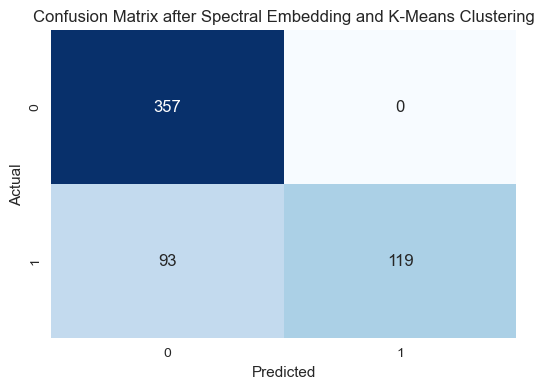

In [52]:
# Comparamos los valores predichos con los reales
print(classification_report(df_se['diagnosis'], df_se['cluster_se']))

# Mostramos la matriz de confusión
conf_matrix_se = confusion_matrix(df_se['diagnosis'], df_se['cluster_se'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_se, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after Spectral Embedding and K-Means Clustering')
plt.show()

El recall para 1 presenta un resultado muy bajo, con lo cual a pesar de que no existan falsos positivos, como ya hemos dicho los falsos negativos son mucho más preocupantes en este caso, por lo que este no sería un buen resultado. Sin embargo esto muestra que la división en tres componentes principales no está del todo desencaminada. Probemos con otro algoritmo.

In [57]:
# Vamos a probar con el modelo Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

# Inicializamos Agglomerative Clustering con 2 clusters
aggclustering = AgglomerativeClustering(n_clusters=2)

# Predecimos los clusters
df_se['agg_cluster'] = aggclustering.fit_predict(X_sc)

# Obtenemos el tamaño de cada cluster
tamano_clusters_agg = df_se['agg_cluster'].value_counts()

# Determinamos el cluster mayoritario
cluster_mayoritario_agg = tamano_clusters_agg.idxmax()

# Asignamos etiquetas basadas en el cluster mayoritario
df_se['agg_cluster'] = df_se['agg_cluster'].apply(lambda x: 0 if x == cluster_mayoritario_agg else 1)

# Mostramos el resultado
print(df_se['agg_cluster'].value_counts())


agg_cluster
0    439
1    130
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.81      1.00      0.90       357
           1       1.00      0.61      0.76       212

    accuracy                           0.86       569
   macro avg       0.91      0.81      0.83       569
weighted avg       0.88      0.86      0.85       569



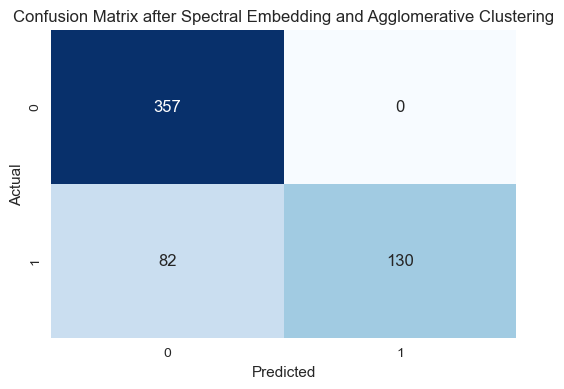

In [56]:
# Comparamos los valores predichos con los reales
print(classification_report(df_se['diagnosis'], df_se['agg_cluster']))

# Mostramos la matriz de confusión
conf_matrix_agg = confusion_matrix(df_se['diagnosis'], df_se['agg_cluster'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_agg, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after Spectral Embedding and Agglomerative Clustering')

plt.show()

Podemos apreciar que, aunque el recall de la clasificación de tumores benignos sea perfecto, aumenta sobremanera la tasa de falsos negativos, con lo cual no vamos a tomar este modelo en cuenta. Probemos ahora con el modelo de Gaussian Mixture nuevamente.

In [63]:
# Probamos con el modelo Gaussian Mixture (GMM)

# Inicializamos GMM con 2 clusters
gmm_se = GaussianMixture(n_components=2,
                        n_init=20,
                        max_iter=500,
                        init_params='k-means++',
                        random_state=42)

# Entrenamos el modelo
gmm_se.fit(X_sc)

# Obtenemos la clasificación en clusters
y_gmm_se = gmm_se.predict(X_sc)

# Añadimos el resultado al DataFrame
df_se['gmm_cluster'] = y_gmm_se

# Comprobamos que el mapeado de valores sea correcto
tamano_clusters_gmm = df_se['gmm_cluster'].value_counts()
cluster_mayoritario_gmm = tamano_clusters_gmm.idxmax()
df_se['gmm_cluster'] = df_se['gmm_cluster'].apply(lambda x: 0 if x == cluster_mayoritario_gmm else 1)

# Mostramos el resultado
print(df_se['gmm_cluster'].value_counts())



gmm_cluster
0    380
1    189
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.93      0.99      0.96       357
           1       0.98      0.88      0.93       212

    accuracy                           0.95       569
   macro avg       0.96      0.93      0.94       569
weighted avg       0.95      0.95      0.95       569



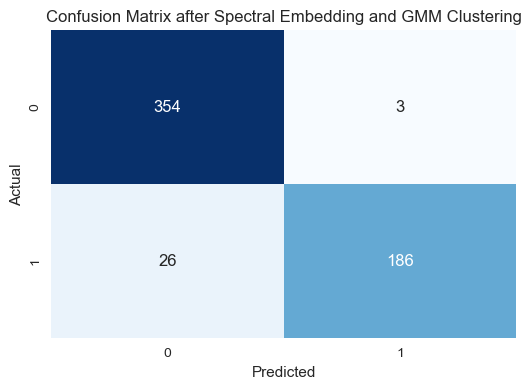

In [72]:
# Comparamos los valores predichos con los reales
print(classification_report(df_se['diagnosis'], df_se['gmm_cluster']))

# Mostramos la matriz de confusión
conf_matrix_gmm_se = confusion_matrix(df_se['diagnosis'], df_se['gmm_cluster'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gmm_se, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after Spectral Embedding and GMM Clustering')

plt.show()

In [78]:
# Calculamos el tiempo de ejecución
start_time = timeit.default_timer()
gmm_se = GaussianMixture(n_components=2,
                        n_init=20,
                        max_iter=500,
                        init_params='k-means++',
                        random_state=42).fit(X_sc)
end_time = timeit.default_timer()
execution_time_gmm_se = end_time - start_time
print("Tiempo de ejecución con GMM y Spectral Embedding:", execution_time_gmm_se, "segundos")


Tiempo de ejecución con GMM y Spectral Embedding: 0.0891985000052955 segundos


Resultados de clustering con GMM y datos completos:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       357
           1       0.91      0.92      0.92       212

    accuracy                           0.94       569
   macro avg       0.93      0.94      0.93       569
weighted avg       0.94      0.94      0.94       569



Resultados de clustering con Kmeans y t-SNE:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       357
           1       0.86      0.95      0.90       212

    accuracy                           0.92       569
   macro avg       0.91      0.93      0.92       569
weighted avg       0.93      0.92      0.92       569



Resultados de clustering con GMM y Spectral Embedding:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       357
           1       0.98      0.88      0.93       212

    accuracy              

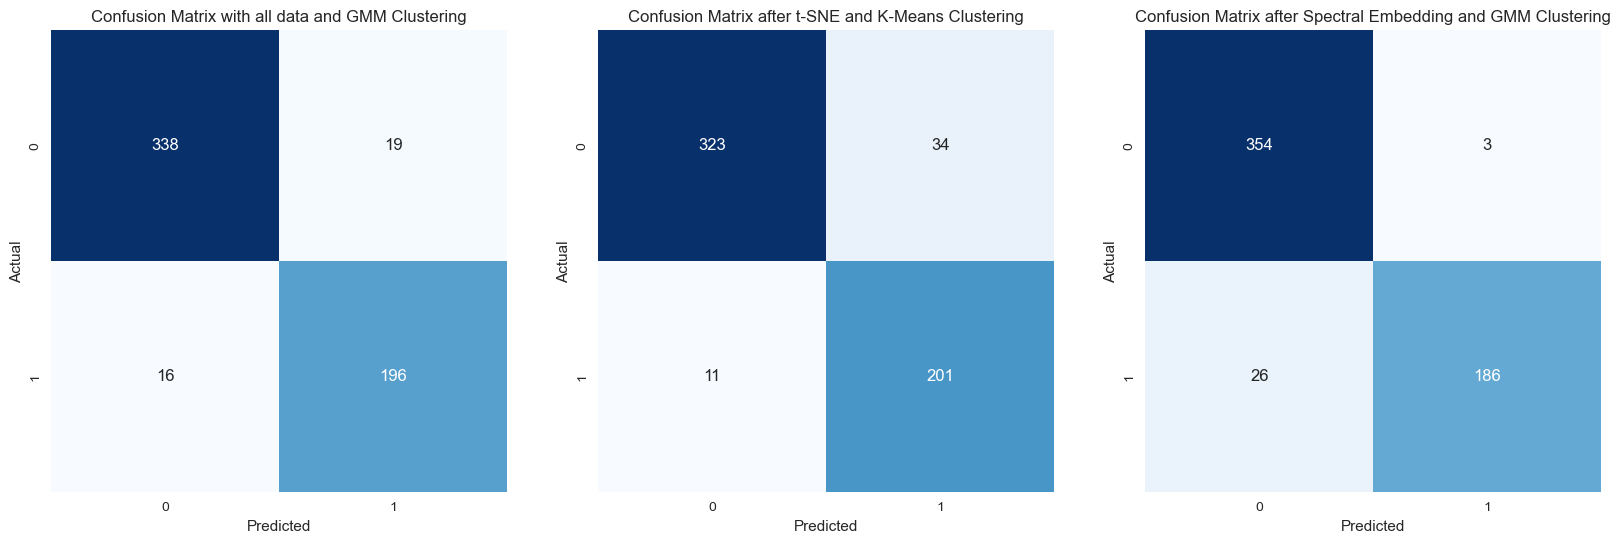

In [80]:
#Comparamos con los resultados de GMM con datos completos y Kmeans con t-SNE
print("Resultados de clustering con GMM y datos completos:")
print(classification_report(df['diagnosis'], df['gmm_cluster']))
print("\n")
print("Resultados de clustering con Kmeans y t-SNE:")
print(classification_report(df_tsne['diagnosis'], df_tsne['cluster_tsne']))
print("\n")
print("Resultados de clustering con GMM y Spectral Embedding:")
print(classification_report(df_se['diagnosis'], df_se['gmm_cluster']))

# Mostramos las matrices de confusión

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix_gmm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with all data and GMM Clustering')

plt.subplot(1, 3, 2)
sns.heatmap(conf_matrix_kmeans, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after t-SNE and K-Means Clustering')

plt.subplot(1, 3, 3)
sns.heatmap(conf_matrix_gmm_se, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after Spectral Embedding and GMM Clustering')

plt.show()


# FASE ADICIONAL - OPTATIVA

##### Profundizar aplicando otros algoritmos de CLUSTERING y reduccion de dimensionalidad, para intentar encontrar un mejor resultado (Opcional)

Como vemos, el uso de Spectral Embedding escogiendo 3 componentes principales, conjuntamente al algoritmo de GMM clustering nos devuelve unos resultados altamente precisos, con el valor de accuracy y f-1 score más elevado de todos los modelos. Este modelo es capaz de predecir los tumores benignos casi a la perfección, sin embargo muestra un ligero aumento del número de falsos negativos, por lo que dadas las métricas que habíamos establecido como claves al inicio, el modelo de K-means tras aplicar una reducción de dimensionalidad de t-SNE a 2 componentes principales parece seguir siendo el mejor modelo, aunque ya podríamos dudar dado que la diferencia es muy escasa, y sin embargo, como en el caso anterior, computacionalmente GMM + SE es mucho menos costoso. Tal vez podría mejorarse esta confianza con un dataset mayor.

In [81]:
# Probamos por último un SE de dos componentes con GMM
se2 = SpectralEmbedding(n_components=2, random_state=42)
X_se2 = se2.fit_transform(X_scaled)

# Inicializamos GMM con 2 clusters
gmm_se2 = GaussianMixture(n_components=2,
                        n_init=20,
                        max_iter=500,
                        init_params='k-means++',
                        random_state=42)

# Entrenamos el modelo
gmm_se2.fit(X_se2)

# Obtenemos la clasificación en clusters
y_gmm_se2 = gmm_se2.predict(X_se2)

# Añadimos el resultado al DataFrame
df_se2 = pd.DataFrame(data=X_se2, columns=['SE1', 'SE2'])
df_se2['diagnosis'] = df['diagnosis']
df_se2['gmm_cluster'] = y_gmm_se2

# Comprobamos que el mapeado de valores sea correcto
tamano_clusters_gmm_se2 = df_se2['gmm_cluster'].value_counts()
cluster_mayoritario_gmm_se2 = tamano_clusters_gmm_se2.idxmax()
df_se2['gmm_cluster'] = df_se2['gmm_cluster'].apply(lambda x: 0 if x == cluster_mayoritario_gmm_se2 else 1)

# Mostramos el resultado
print(df_se2['gmm_cluster'].value_counts())

gmm_cluster
0    355
1    214
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.95      0.94      0.94       357
           1       0.90      0.91      0.91       212

    accuracy                           0.93       569
   macro avg       0.92      0.93      0.92       569
weighted avg       0.93      0.93      0.93       569



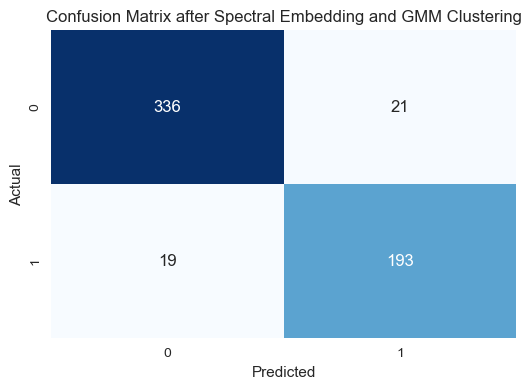

In [82]:
# Comparamos los valores predichos con los reales
print(classification_report(df_se2['diagnosis'], df_se2['gmm_cluster']))

# Mostramos la matriz de confusión
conf_matrix_gmm_se2 = confusion_matrix(df_se2['diagnosis'], df_se2['gmm_cluster'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gmm_se2, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after Spectral Embedding and GMM Clustering')

plt.show()

In [83]:
# Evaluamos el tiempo de ejecución
start_time = timeit.default_timer()
gmm_se2 = GaussianMixture(n_components=2,
                        n_init=20,
                        max_iter=500,
                        init_params='k-means++',
                        random_state=42).fit(X_se2)
end_time = timeit.default_timer()
execution_time_gmm_se2 = end_time - start_time
print("Tiempo de ejecución con GMM y Spectral Embedding de 2 componentes:", execution_time_gmm_se2, "segundos")

Tiempo de ejecución con GMM y Spectral Embedding de 2 componentes: 0.0819513000024017 segundos


Aquí podemos ver como el resultado mejora en el recall pero empeora en todos los demás valores, lo que nos lleva a pensar que la duda inicial entre generar 2 o 3 componentes principales no iba tan desencaminada. Esta combinación sigue constituyendo un muy buen modelo, con buenos resultados y escaso coste computacional.